In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
import lightgbm as lgb

sns.set(style="whitegrid")


In [2]:

df = pd.read_csv("../data/raw/creditcard.csv")
X = df.drop("Class", axis=1)
y = df["Class"]

# اسکیل کردن داده‌ها (طبق پیشنهاد مقاله FROID)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Data ready and scaled with RobustScaler.")


Data ready and scaled with RobustScaler.


In [3]:
#  تولید ویژگی‌های Outlier Detection
print("Generating OD features... (This may take a minute)")

# 1. Isolation Forest
iso_forest = IsolationForest(n_estimators=100, random_state=42, contamination=0.01)
X_train_iso = iso_forest.fit_predict(X_train)
X_test_iso = iso_forest.predict(X_test)

# 2. Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=20, novelty=True)
lof.fit(X_train)
X_train_lof = lof.decision_function(X_train)
X_test_lof = lof.decision_function(X_test)

# اضافه کردن به دیتاست
X_train_froid = X_train.copy()
X_test_froid = X_test.copy()

X_train_froid['IF_Score'] = X_train_iso
X_train_froid['LOF_Score'] = X_train_lof
X_test_froid['IF_Score'] = X_test_iso
X_test_froid['LOF_Score'] = X_test_lof

print("OD features added.")


Generating OD features... (This may take a minute)


c:\Users\Saeid\Desktop\fraud-thesis\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\Saeid\Desktop\fraud-thesis\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


OD features added.


In [4]:
#  تولید ویژگی‌های Feature Reduction (PCA)
pca = PCA(n_components=5, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# اضافه کردن ویژگی‌های PCA به دیتاست نهایی
for i in range(5):
    X_train_froid[f'PCA_{i+1}'] = X_train_pca[:, i]
    X_test_froid[f'PCA_{i+1}'] = X_test_pca[:, i]

print(f"FR features added. Total features now: {X_train_froid.shape[1]}")


FR features added. Total features now: 37


In [5]:
#  آموزش مدل روی ویژگی‌های FROID
clf_froid = lgb.LGBMClassifier(random_state=42, class_weight='balanced', verbosity=-1)
print("Training FROID model...")
clf_froid.fit(X_train_froid, y_train)

y_pred_froid = clf_froid.predict(X_test_froid)
y_probs_froid = clf_froid.predict_proba(X_test_froid)[:, 1]

print("FROID Model Training Finished.")


Training FROID model...
FROID Model Training Finished.


In [6]:
#  گزارش نتایج FROID
print("\n--- FROID Classification Report ---")
print(classification_report(y_test, y_pred_froid))

froid_roc = roc_auc_score(y_test, y_probs_froid)
froid_pr = average_precision_score(y_test, y_probs_froid)

print(f"FROID ROC-AUC: {froid_roc:.4f}")
print(f"FROID PR-AUC (Average Precision): {froid_pr:.4f}")



--- FROID Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

FROID ROC-AUC: 0.9589
FROID PR-AUC (Average Precision): 0.8561


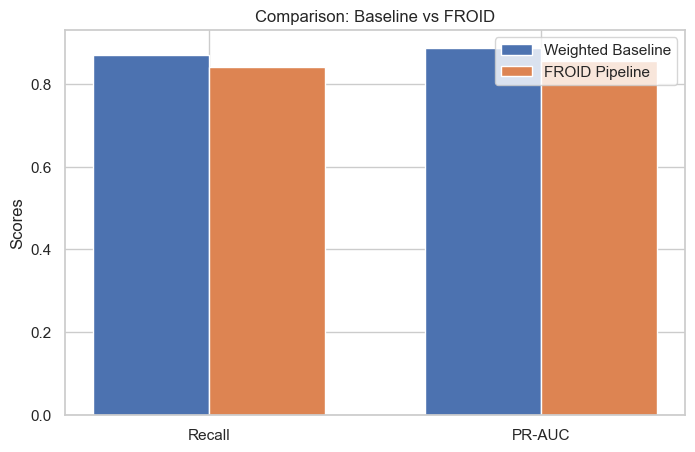

In [7]:
# رسم مقایسه Recall و PR-AUC
metrics = ['Recall', 'PR-AUC']
baseline_vals = [0.87, 0.8864]
froid_vals = [0.84, 0.8561]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, baseline_vals, width, label='Weighted Baseline')
ax.bar(x + width/2, froid_vals, width, label='FROID Pipeline')

ax.set_ylabel('Scores')
ax.set_title('Comparison: Baseline vs FROID')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
plt.show()


In [8]:
#  بهینه‌سازی ابرپارامترهای LightGBM با Optuna روی داده‌های FROID
import optuna
from sklearn.metrics import average_precision_score
import warnings
warnings.filterwarnings('ignore')

# خاموش کردن لوگ‌های اضافی اپتونا برای تمیزی خروجی
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # تعریف فضای جستجوی پارامترها
    params = {
        'objective': 'binary',
        'metric': 'average_precision',
        'boosting_type': 'gbdt',
        'random_state': 42,
        'verbosity': -1,
        'class_weight': 'balanced',  # حفظ تعادل کلاس‌ها
        
        # پارامترهایی که اپتونا باید بهینه کند
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    
    # آموزش مدل با پارامترهای پیشنهادی این Trial
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train_froid, y_train)
    
    # پیش‌بینی روی داده‌های تست
    y_probs = model.predict_proba(X_test_froid)[:, 1]
    
    # محاسبه PR-AUC به عنوان سنجه هدف
    pr_auc = average_precision_score(y_test, y_probs)
    return pr_auc

# ایجاد یک مطالعه (Study) برای بیشینه‌سازی PR-AUC
study = optuna.create_study(direction='maximize')
print("Starting Hyperparameter Tuning with Optuna... (Running 30 trials)")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("\n--- Tuning Optimization Finished! ---")
print(f"Best PR-AUC Score: {study.best_value:.4f}")
print("Best Hyperparameters found:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")


Starting Hyperparameter Tuning with Optuna... (Running 30 trials)


  0%|          | 0/30 [00:00<?, ?it/s]


--- Tuning Optimization Finished! ---
Best PR-AUC Score: 0.8935
Best Hyperparameters found:
  n_estimators: 273
  learning_rate: 0.1138487760226873
  num_leaves: 57
  max_depth: 9
  min_child_samples: 92
  subsample: 0.9037231488200491
  colsample_bytree: 0.9990646643289502
  reg_alpha: 9.7117700327428e-08
  reg_lambda: 0.001463724083387111


In [9]:
#  آموزش مدل نهایی FROID با بهترین پارامترهای یافت شده
best_params = study.best_params
# اضافه کردن تنظیمات ثابت
best_params['objective'] = 'binary'
best_params['class_weight'] = 'balanced'
best_params['random_state'] = 42
best_params['verbosity'] = -1

# آموزش مدل نهایی
best_clf_froid = lgb.LGBMClassifier(**best_params)
best_clf_froid.fit(X_train_froid, y_train)

# ارزیابی نهایی
y_pred_opt = best_clf_froid.predict(X_test_froid)
y_probs_opt = best_clf_froid.predict_proba(X_test_froid)[:, 1]

print("\n--- Optimized FROID Classification Report ---")
print(classification_report(y_test, y_pred_opt))

opt_roc = roc_auc_score(y_test, y_probs_opt)
opt_pr = average_precision_score(y_test, y_probs_opt)

print(f"Optimized FROID ROC-AUC: {opt_roc:.4f}")
print(f"Optimized FROID PR-AUC (Average Precision): {opt_pr:.4f}")



--- Optimized FROID Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.91      0.84      0.87        98

    accuracy                           1.00     56962
   macro avg       0.96      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Optimized FROID ROC-AUC: 0.9716
Optimized FROID PR-AUC (Average Precision): 0.8935


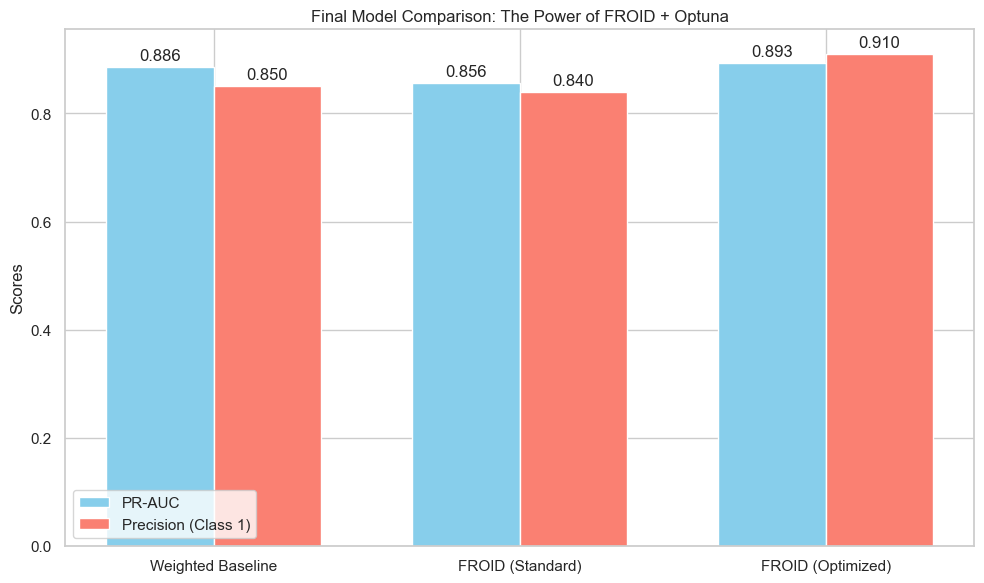

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# داده‌های نهایی برای مقایسه
models = ['Weighted Baseline', 'FROID (Standard)', 'FROID (Optimized)']
pr_auc_scores = [0.8864, 0.8561, 0.8935]
precision_scores = [0.85, 0.84, 0.91] # مقادیر حدودی بر اساس گزارش‌های قبلی شما

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# رسم میله‌های PR-AUC
rects1 = ax.bar(x - width/2, pr_auc_scores, width, label='PR-AUC', color='skyblue')
# رسم میله‌های Precision
rects2 = ax.bar(x + width/2, precision_scores, width, label='Precision (Class 1)', color='salmon')

ax.set_ylabel('Scores')
ax.set_title('Final Model Comparison: The Power of FROID + Optuna')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# اضافه کردن برچسب اعداد روی میله‌ها
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()
